# Colouring by expression: tables, layers, and gene symbols

When you colour an element by a gene, `spatialdata-plot` reads the value from the **table** that
annotates it. Three arguments control exactly which values it uses: `table_name` (which table),
`table_layer` (which matrix within that table), and `gene_symbols` (how to look a gene up in `var`).
By the end you should be able to:

- Colour spots by a gene's expression.
- Read from a specific matrix with `table_layer` (e.g. raw counts vs a normalised layer).
- Look genes up by symbol when `var` is indexed by IDs, with `gene_symbols`.
- Choose between several annotating tables with `table_name`.

We use the real 10x **Visium** mouse-brain dataset from `squidpy`. It ships with a single raw table, so
we **construct** the extra layer, the gene-ID index, and the second table in-notebook to demonstrate
each argument — real datasets often already carry them.

## Setup

In [1]:
import numpy as np
import scipy.sparse as sp
import anndata as ad
import squidpy as sq
from spatialdata import SpatialData
from spatialdata.models import TableModel

import spatialdata_plot  # noqa: F401  # registers the .pl accessor

sdata = sq.datasets.visium_hne_sdata()
table = sdata.tables["adata"]
gene = "Mbp"  # myelin basic protein, a white-matter marker
sdata

/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


INFO     Loading existing dataset from data/spatialdata/visium_hne_sdata.zarr                                      


/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/squidpy/datasets/_downloader.py:209: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  return sd.read_zarr(zarr_path)


/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/examples/data/spatialdata/visium_hne_sdata.zarr
├── Images
│     └── 'hne': DataTree[cyx] (3, 11757, 11291), (3, 5878, 5645), (3, 2939, 2822), (3, 1469, 1411)
├── Shapes
│     └── 'spots': GeoDataFrame shape: (2688, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (2688, 18078)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), spots (Shapes)

## 1. Colour by a gene

Passing a `var` name to `color=` colours each spot by that gene's expression, from the annotating
table's main matrix (`X`).

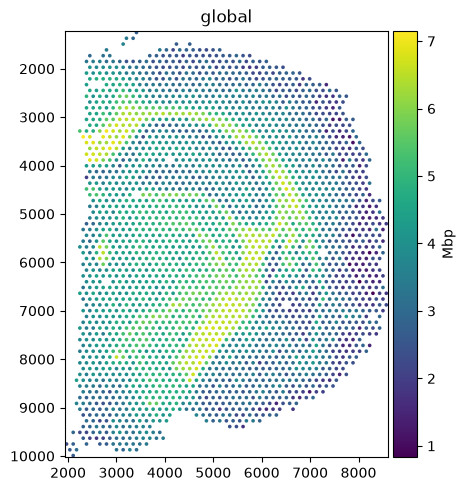

In [2]:
sdata.pl.render_shapes("spots", color=gene).pl.show()

## 2. Choosing the matrix — `table_layer`

A table can hold several matrices in `.layers` (raw counts, normalised, scaled). `table_layer=` picks
which one to colour from. Here we add a log-normalised layer and compare it with the raw `X` above —
the log scale compresses the bright outliers and reveals more structure.

(Setup — real data often already carries such a layer.) Note `table_layer` only affects
gene-expression colouring, i.e. a `var_names` lookup; colouring by an `obs` column ignores it.

(This appends the layer in place on the live table — harmless, since it only adds to `.layers`; the
`gene_symbols` and `table_name` demos below use throwaway copies so they never touch the original.)

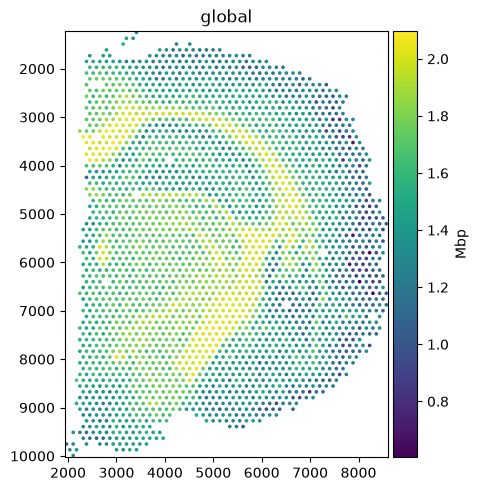

In [3]:
# setup: add a normalised layer (your data may already have one)
raw = table.X.toarray() if sp.issparse(table.X) else table.X
table.layers["lognorm"] = np.log1p(raw)

sdata.pl.render_shapes("spots", color=gene, table_layer="lognorm").pl.show()

## 3. Looking up by symbol — `gene_symbols`

Many datasets index `var` by a stable ID (Ensembl) and keep the human-readable symbol in a column.
`color=` then can't find a symbol directly. `gene_symbols=` names the column to map through. We
simulate that layout on a **copy** of the table and render it through a throwaway `SpatialData`, so the
original table stays symbol-indexed and every earlier cell keeps working. (10x tables carry a `gene_ids` column; adapt the column name for other data.)

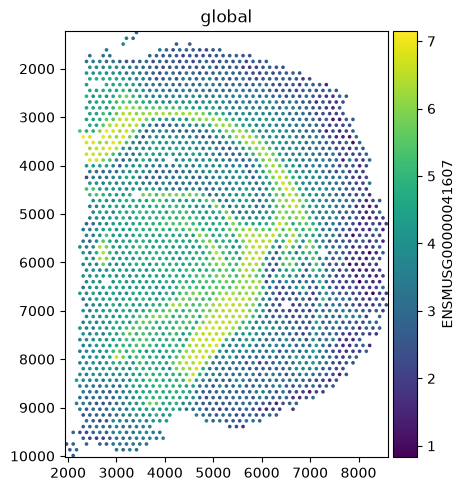

In [4]:
# setup — skip on your own data: simulate an ID-indexed table on a copy so the original is untouched
table_ids = table.copy()
table_ids.var["symbol"] = table_ids.var_names
table_ids.var.index = list(table_ids.var["gene_ids"].values)  # var now indexed by Ensembl IDs

# render from a lightweight SpatialData that reuses the spots and the copied, ID-indexed table
# color= still takes the symbol; gene_symbols tells the renderer which var column to map through
demo = SpatialData(shapes={"spots": sdata.shapes["spots"]}, tables={"adata": table_ids})
demo.pl.render_shapes("spots", color=gene, gene_symbols="symbol").pl.show()

## 4. Choosing the table — `table_name`

An element can be annotated by more than one table. When there is only one, it is used automatically;
with several you disambiguate with `table_name=`. We add a second table of per-spot QC flags and
colour by it.

A table links to its element through three keys in `table.uns['spatialdata_attrs']`: `region` (the
annotated element), `region_key` (the obs column naming that element for each row), and `instance_key`
(the obs column giving each row's id within it). We assemble the two tables into a throwaway
`SpatialData` so the original object is left untouched.

WARNING  render_shapes: Converting copy of 'qc' column to categorical dtype for categorical plotting. Consider     
         converting before plotting.                                                                               


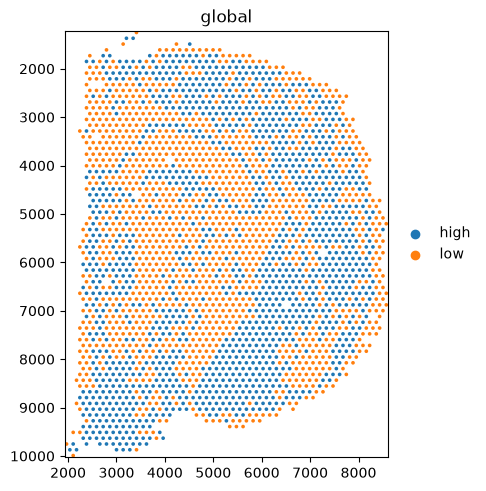

In [5]:
attrs = table.uns["spatialdata_attrs"]
region_key = attrs["region_key"]      # obs column naming which element each row annotates
instance_key = attrs["instance_key"]  # obs column giving the row id within that element
region = attrs["region"]              # the annotated element ("spots")

qc_obs = table.obs[[region_key, instance_key]].copy()
qc_obs["qc"] = np.where(table.obs["total_counts"] > table.obs["total_counts"].median(), "high", "low")
qc_table = TableModel.parse(
    ad.AnnData(obs=qc_obs), region=region, region_key=region_key, instance_key=instance_key
)

# two tables annotate the same spots; table_name picks which one to colour from
demo = SpatialData(shapes={"spots": sdata.shapes["spots"]}, tables={"adata": table, "qc": qc_table})
demo.pl.render_shapes("spots", color="qc", table_name="qc").pl.show()

## Summary

- Colouring by a gene reads from the **annotating table** of the element.
- `table_layer=` selects the matrix within that table (e.g. raw `X` vs a `lognorm` layer), for
  gene-expression colouring only — an `obs`-column colour ignores it.
- `gene_symbols=` names the `var` column of symbols to look `color=` up in, for ID-indexed tables.
- `table_name=` picks the table when an element has more than one; with a single table it is
  automatic.

Together these let you point `render_*` at exactly the values you want to visualise, without
reshaping your `SpatialData` object.

## For reproducibility

In [6]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,squidpy,anndata,numpy

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.14.1

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
squidpy         : 1.8.2
anndata         : 0.12.17
numpy           : 2.4.6

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

